# K-Means Clustering
## Used for Dengu Risk Zone Clustering
### Import required modules:
- pandas
- StandardScaler
- KMeans
- matplotlib.pyplot
- seaborn

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import  KMeans
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

## Load dengu predictions data

In [2]:
df = pd.read_csv("./datasets/dengu_predictions_in_district_final.csv")
df.head()

,Year,dengue_total,Location,Month,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation,daily_rain_density,average_humidity,avg_soil_moisture,avg_soil_temperature,avg_snowfall,avg_precipitation
0,2022,1,RUPANDEHI,Apr,27.541040,0.140000,40.643658,0.180724,25.653076,0.00,0.140000,low,moderate,moderate,high,none,low
1,2024,0,SURKHET,Jan,21.709210,2.438710,54.626945,0.282942,18.936808,0.00,2.438710,low,moderate,moderate,moderate,none,low
2,2022,0,RASUWA,Jul,-10.367068,0.000000,47.298428,0.323489,-2.997343,1.53,2.171428,no,moderate,high,low,light,low
3,2022,0,BAITADI,May,20.027569,4.980001,85.651030,0.473050,21.403994,0.00,4.980001,moderate,extreme,extreme,moderate,none,moderate
4,2024,4,KANCHANPUR,Feb,13.511224,0.216129,79.257805,0.300749,17.036068,0.00,0.216129,low,high,high,moderate,none,low


### Keep only numeric data

In [3]:
df_numeric = df.select_dtypes(exclude="object")
df_numeric.head()

,Year,dengue_total,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation
0,2022,1,27.541040,0.140000,40.643658,0.180724,25.653076,0.00,0.140000
1,2024,0,21.709210,2.438710,54.626945,0.282942,18.936808,0.00,2.438710
2,2022,0,-10.367068,0.000000,47.298428,0.323489,-2.997343,1.53,2.171428
3,2022,0,20.027569,4.980001,85.651030,0.473050,21.403994,0.00,4.980001
4,2024,4,13.511224,0.216129,79.257805,0.300749,17.036068,0.00,0.216129


### Scale features

In [4]:
scaler = StandardScaler()

X = scaler.fit_transform(X=df_numeric)

### Create four clusters and train

In [5]:
k = 3

k_means = KMeans(n_clusters=k, random_state=42)
clusters = k_means.fit_predict(X)

df_numeric["clusters"] = clusters

### Reduce features to 2D

In [6]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X)

In [7]:
df_numeric["PC1"] = x_pca[:, 0]
df_numeric["PC2"] = x_pca[:, 1]

### See if PCA is present

In [8]:
df_numeric.head()

,Year,dengue_total,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation,clusters,PC1,PC2
0,2022,1,27.541040,0.140000,40.643658,0.180724,25.653076,0.00,0.140000,1,-1.463264,2.600569
1,2024,0,21.709210,2.438710,54.626945,0.282942,18.936808,0.00,2.438710,1,-0.712437,1.065099
2,2022,0,-10.367068,0.000000,47.298428,0.323489,-2.997343,1.53,2.171428,2,-3.159677,-2.765878
3,2022,0,20.027569,4.980001,85.651030,0.473050,21.403994,0.00,4.980001,0,1.476220,-0.269521
4,2024,4,13.511224,0.216129,79.257805,0.300749,17.036068,0.00,0.216129,1,-0.602713,0.363463


### Display Cluster Summary

In [9]:
cluster_summary = df_numeric.groupby("clusters").mean()

cluster_summary

,Year,dengue_total,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation,PC1,PC2
clusters,,,,,,,,,,,
0,2023.000000,62.201889,21.114729,13.005434,85.769256,0.388689,21.221514,0.009207,13.018586,2.433125,-0.401398
1,2023.000147,62.769268,18.299698,1.601983,67.469211,0.272193,18.554756,0.003904,1.607552,-0.629384,0.865869
2,2022.999586,13.839645,1.012600,1.558989,61.364279,0.331013,3.035119,1.154265,3.206026,-1.807680,-1.850100


### Summary Evaluation

The K-Means clustering model was evaluated by analyzing the characteristics of each cluster based on dengue cases and environmental factors. Since K-Means is an unsupervised learning algorithm, the generated cluster labels do not represent predefined risk categories. Therefore, clusters were interpreted by comparing their average dengue cases (dengue_total) along with climate-related features such as temperature, humidity, rainfall, and precipitation. Cluster 0 and Cluster 1 showed significantly higher average dengue cases compared to Cluster 2, indicating more favorable conditions for dengue transmission. Cluster 2 showed the lowest dengue cases along with colder temperature and lower precipitation, representing less favorable conditions. Based on these observations, the clusters were named Higher Dengue Risk Cluster (Cluster 0), Higher Dengue Risk Cluster (Cluster 1), and Lower Dengue Risk Cluster (Cluster 2). These labels are assigned based on the relative patterns observed in the dataset rather than the original K-Means cluster numbers.

### Visualize all clusters

Visualized All clusters with renaming clusters 0, 1 and 2 as "Higher Dengue Risk (Type A)", "Higher Dengue Risk (Type B)", "Lower Dengu Risk".

In [10]:
df_numeric["cluster_category"] = df_numeric["clusters"].map({
    0: "High Dengue Risk (Type A)",
    1: "High Dengue Risk (Type B)",
    2: "Low Dengue Risk"
})

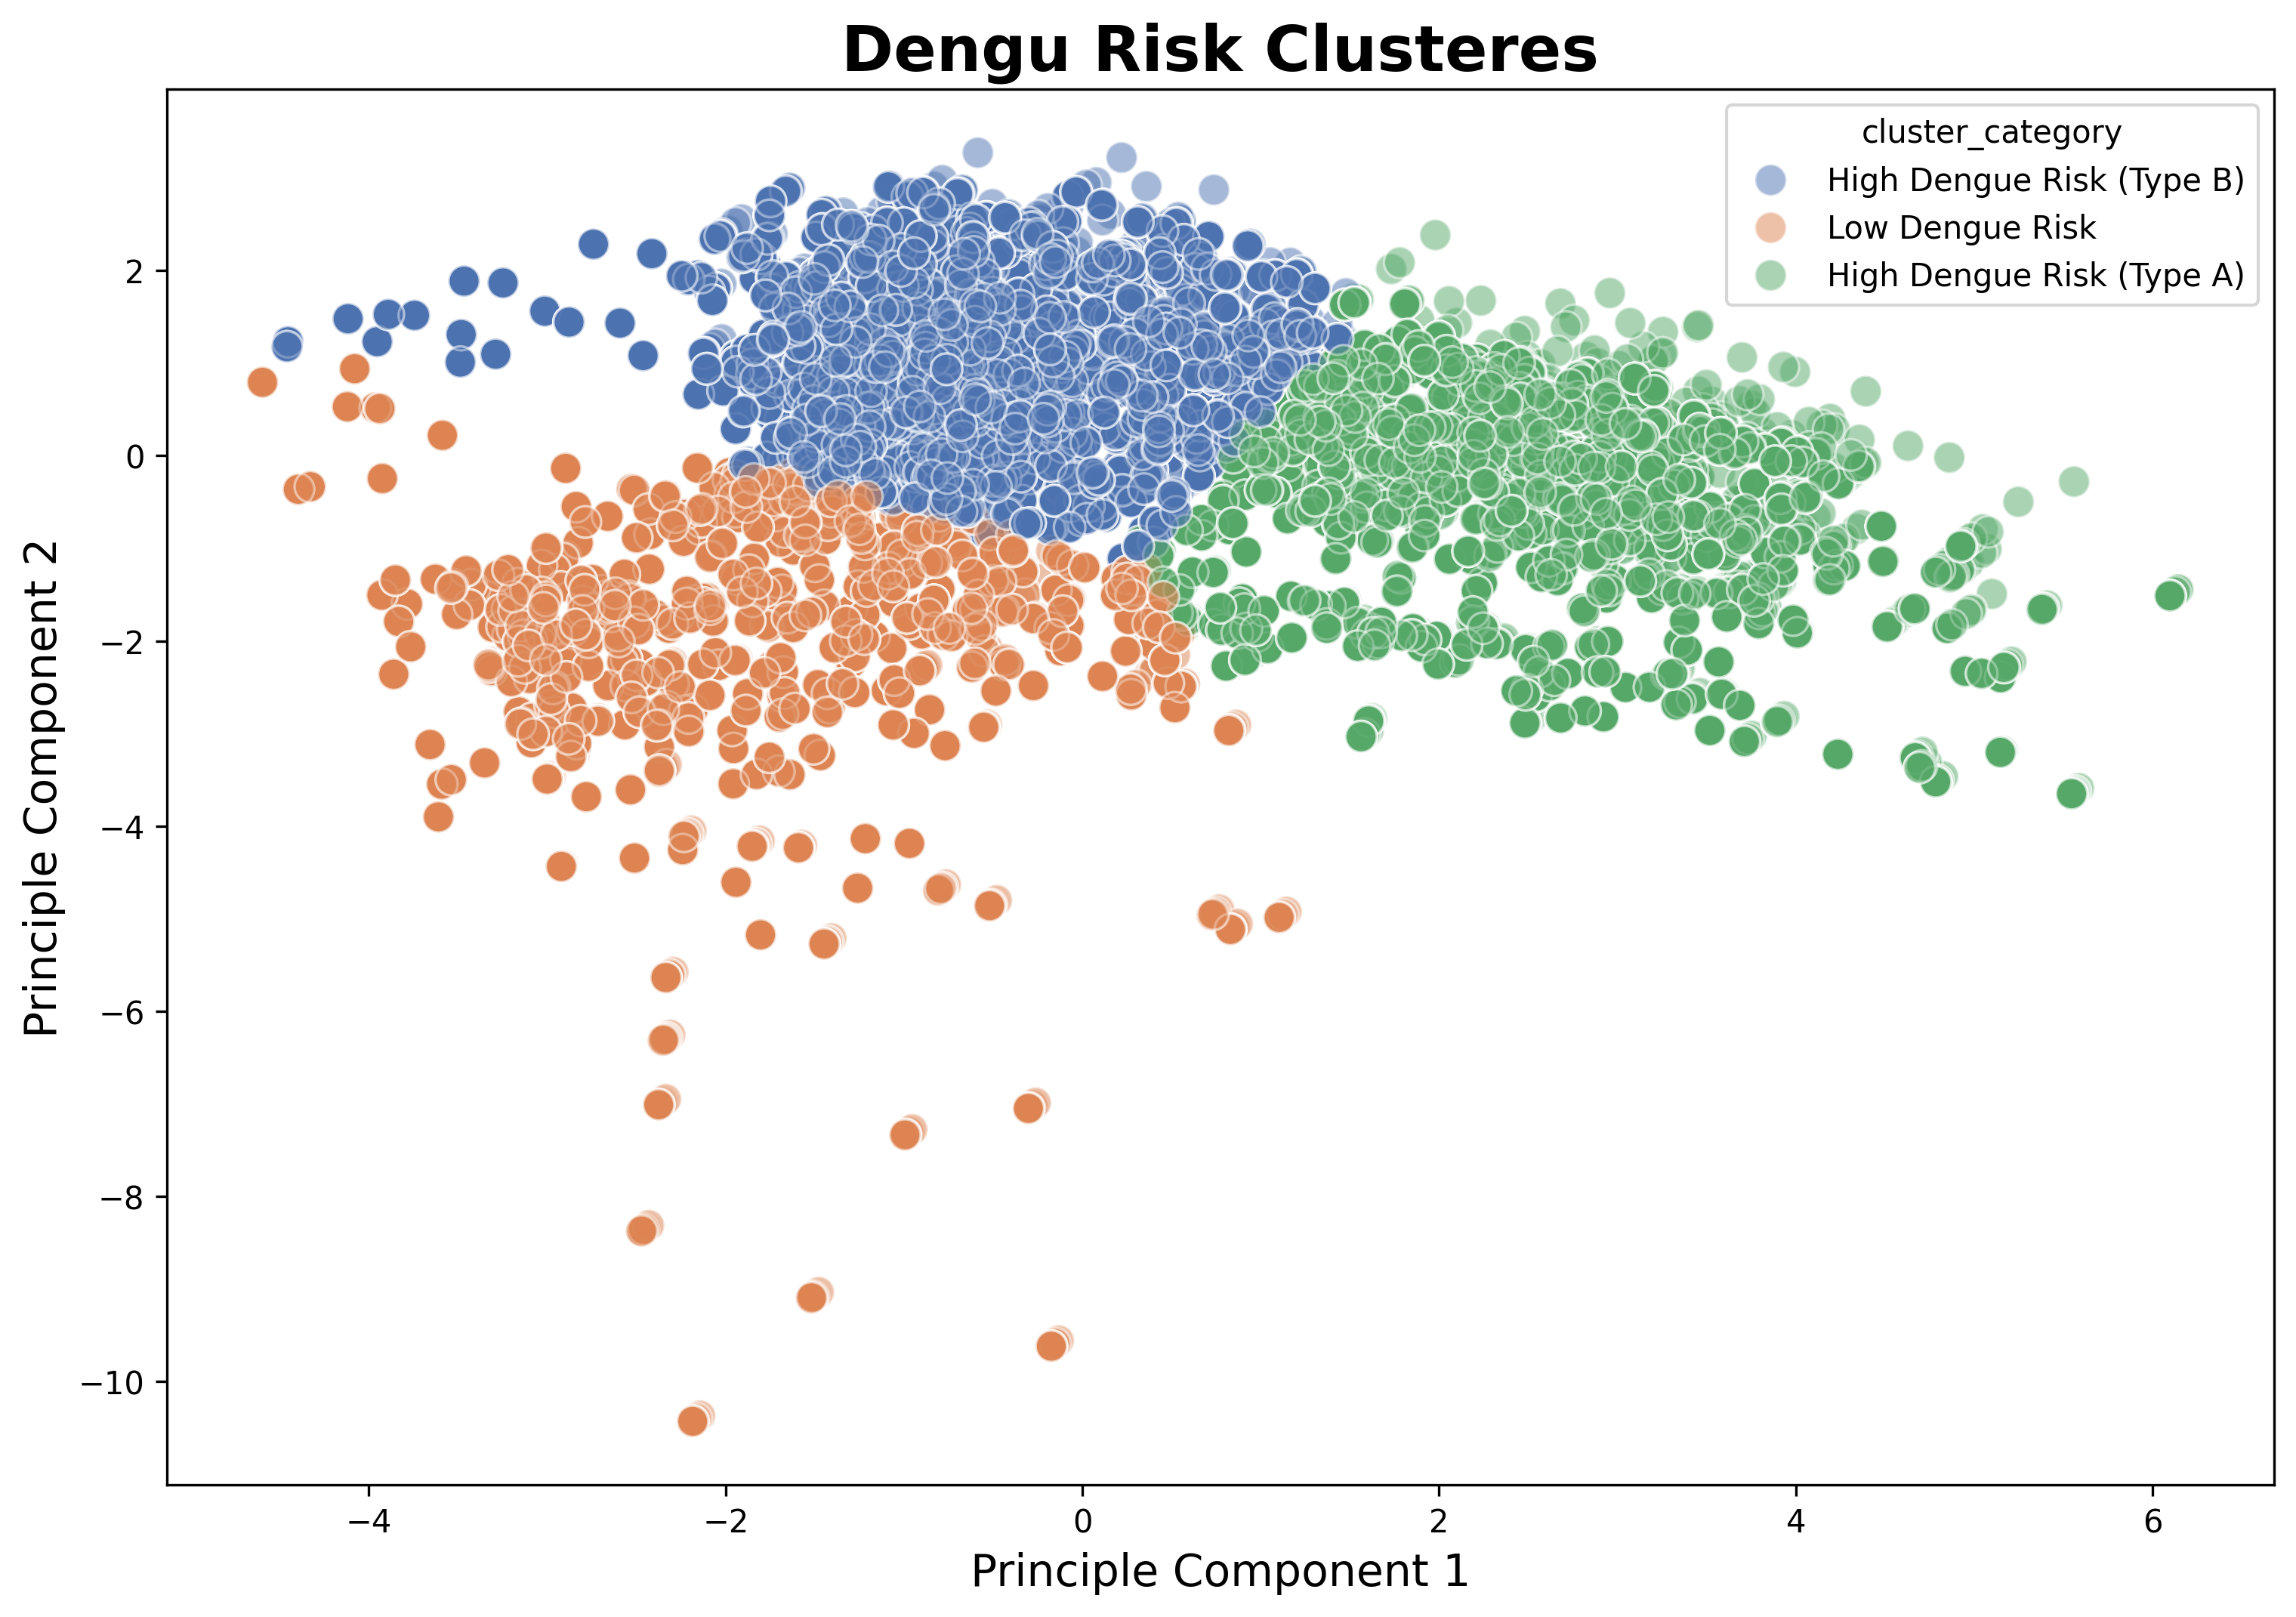

In [12]:
plt.figure(figsize=(12, 8), dpi=300)

sns.scatterplot(
    data=df_numeric,
    x = "PC1",
    y = "PC2",
    hue = "cluster_category",
    s = 100, # Point sizes
    alpha = 0.5 ,# transparency
    palette="deep" 
)

plt.title("Dengu Risk Clusteres", fontsize=20, fontweight="bold")
plt.xlabel("Principle Component 1",fontsize=14)
plt.ylabel("Principle Component 2", fontsize=14)
plt.savefig("./resources/Dengu_Risk_Clusters_KMeans.png", dpi=300)
plt.show()